# Starting tests to model 2025wny

## Drive setup and imports

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
#base_dir = '/content/drive/MyDrive/repos/GL-PS'

base_dir = '/global/u1/o/osoler/repos/GL-PS'
local = True
if local:
    base_dir = '/Users/oscar/LB/GL-PS'
import os
os.chdir(base_dir)
%ls

README.md  modeling/  notebooks/ src/       test.txt


In [2]:
!nvidia-smi
# When running from google drive
#!pip install corner
#!pip install lenstronomy==1.13.2
#!pip install gigalens --no-deps

# When running on NERSC
import sys
gigalens_base_dir = '/global/u1/o/osoler/gigalens/src'

if local:
    gigalens_base_dir = '/Users/oscar/LB/grav_lens/gigalens/src'
if gigalens_base_dir not in sys.path:
    sys.path.append(gigalens_base_dir)
print(sys.path)

zsh:1: command not found: nvidia-smi
['/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/oscar/LB/GL-PS/.venv/lib/python3.13/site-packages', '/Users/oscar/LB/grav_lens/gigalens/src']


In [45]:
import sys
# import modeling functions
from importlib import reload
import src.flux_ratios_pipeline_funcs
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

# import gigalens functions
from gigalens.tf.inference import ModellingSequence
from gigalens.tf.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.tf.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.tf.profiles.light import sersic
from gigalens.tf.profiles.mass import sis, shear, epl, sie
from tensorflow_probability import distributions as tfd, bijectors as tfb

flux_ratios_pipeline_funcs.py version: 0.2.9


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import add_scalebar
from astropy.stats import sigma_clipped_stats



## Observational data



In [5]:

data_dir = base_dir + '/modeling/2025wny/data/'
psfr_path = 'nirc2_psf_psfr_stacked.npy'
psf_path = 'nirc2_psf_stacked.npy'
image_fits = 'nirc2_wny_full.fits'
image_fits_clean = 'nirc2_wny_full_clean.fits'
psf_photutil_path = 'wny_photutil_psf_fit.csv'

with fits.open(data_dir + image_fits) as hdul:
  heads = hdul[0].header
  data = hdul[0].data
  hdul.close()

  heads_clean = hdul[0].header
  heads_list = ['CD1_1', 'CD1_2', 'CD2_1', 'CD2_2']
  for hl in heads_list:
    heads_clean[hl] = float(heads[hl])
  heads_clean['RADESYSa'] = heads['RADECSYS']
wcs = WCS(heads_clean)

psfr = np.load(data_dir + psfr_path)
psf = np.load(data_dir + psf_path)
psf_photutil = pd.read_csv(data_dir + psf_photutil_path)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'. [astropy.wcs.wcs]


In [6]:
psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


SKy mean: -8.86e-02, sky median: -8.88e-02, sky std: 4.88e-02


/var/folders/lp/gmwtz0k15l9131lfg2fd97bh0000gn/T/ipykernel_10145/1939223510.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 1000x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax = ax[0],


Text(0.5, 1.0, 'psf')

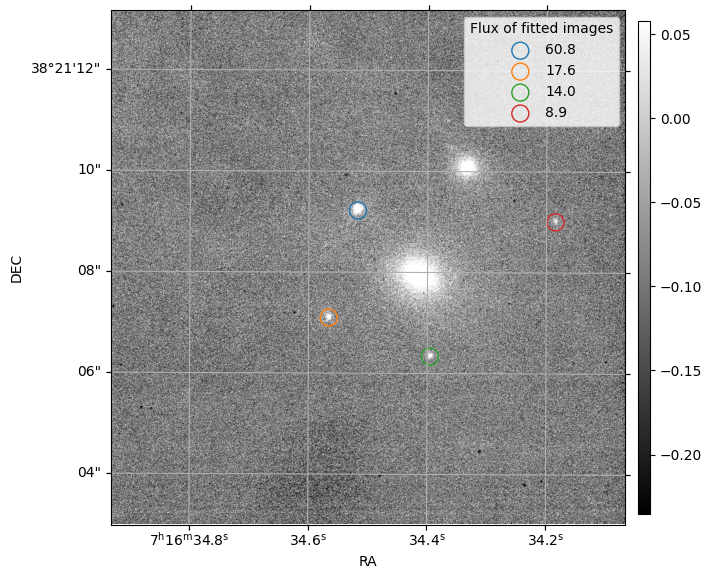

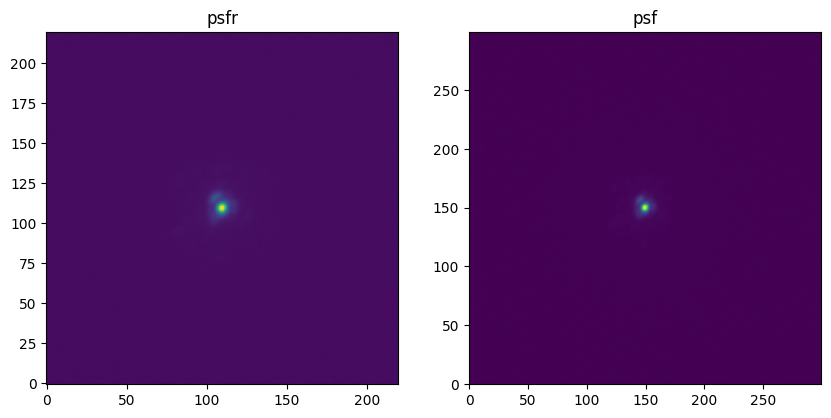

In [7]:
pixel_fit = np.array([psf_photutil['y_fit'].values, psf_photutil['x_fit'].values]).T
pixscale = 0.009952 # arcsec/px
exptime = 180

sky_mean, sky_median, sky_std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)
print('SKy mean: %.2e, sky median: %.2e, sky std: %.2e'%(sky_mean, sky_median, sky_std))
bkg_rms = sky_std

stretch = 'linear'
percent = (5,99)
vminmax = (sky_mean - 3*sky_std,sky_mean + 3*sky_std)
# norm
norm = simple_norm(data, stretch,
                   #min_percent=percent[0], max_percent=percent[1],
                   #vmin = vminmax[0], vmax = vminmax[1])
                   min_cut = vminmax[0], max_cut = vminmax[1])
# figure
fig, ax = plt.subplots(1,1, figsize=(8,8))
fog, ax2 = plt.subplots(1,2, figsize=(10,5))
ax = [ax, ax2[0], ax2[1]]
ax[0].remove()
ax[0] = fig.add_subplot(1,1,1,projection=wcs)
im = ax[0].imshow(data, cmap='gray', origin = 'lower', norm = norm)
plt.colorbar(im, ax = ax[0],
             fraction = 0.15, aspect = 40, shrink = 0.8, pad = 0.02)
# images
for i in range(len(psf_photutil)):
  phot_row = psf_photutil.iloc[i]
  ax[0].scatter(phot_row['x_fit'], phot_row['y_fit'], label = '%.1f'%phot_row['flux_fit'],
             marker = 'o', s  = 150,
             facecolor = 'none', edgecolors=plt.get_cmap('tab10')(i), alpha = 1)
ax[0].legend(title = 'Flux of fitted images')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[0].grid()
# psfs
ax[1].imshow(psfr, origin = 'lower')
ax[1].set_title('psfr')

ax[2].imshow(psf, origin = 'lower')
ax[2].set_title('psf')

[[625 491]
 [495 611]
 [709 709]]


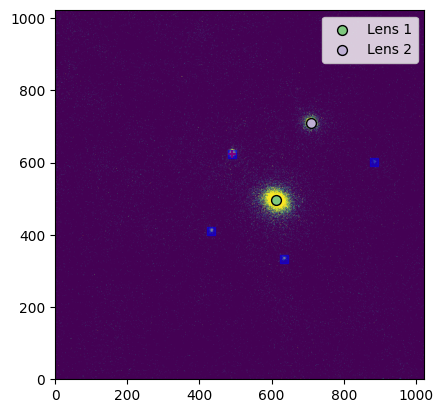

In [8]:
bp_converter = BrightestPoints(number_of_images = 3, num_pixels = data.shape[0],
                             grid_size = 50, delta_pix = pixscale,
                             supersample = 1)
bp_px = bp_converter.find_brightest_points(data)
print(bp_px.numpy())
plt.imshow(data, origin = 'lower', vmin=0, vmax = 0.1)
plt.scatter(bp_px[:,1], bp_px[:,0], c = 'r', marker='+')
plt.scatter(psf_photutil['x_fit'], psf_photutil['y_fit'], c = 'b', marker='s', alpha = 0.5)

lens1_px = bp_px[1]
lens2_px = bp_px[2]
pixel_lens = np.array([lens1_px, lens2_px])
for i, len_px in enumerate([lens1_px, lens2_px]):
  plt.scatter(len_px[1], len_px[0], marker='o', alpha = 1, s = 50, linewidths=1,
              edgecolors='black', facecolor = plt.get_cmap('Accent')(i), label = 'Lens %d'%(i+1))
plt.legend()

In [9]:

bp_converter = BrightestPoints(number_of_images = 4, num_pixels = data.shape[0],
                             grid_size = 20, delta_pix = pixscale,
                             supersample = 1)
x_arcsec, y_arcsec = bp_converter.pix_to_arcsec(pixel_fit)
x_arcsec_lens, y_arcsec_lens = bp_converter.pix_to_arcsec(pixel_lens)
print(x_arcsec, y_arcsec)

print(x_arcsec_lens, y_arcsec_lens)

flux_truth_test = tf.constant(psf_photutil['flux_fit'], dtype=tf.float32)
print(flux_truth_test)

tf.Tensor([-0.20401621 -0.78123224  1.2191198   3.70712   ], shape=(4,), dtype=float32) tf.Tensor([ 1.1195998  -1.0001762  -1.7764323   0.88075185], shape=(4,), dtype=float32)
tf.Tensor([0.9902238 1.9655199], shape=(2,), dtype=float32) tf.Tensor([-0.1642082  1.9655199], shape=(2,), dtype=float32)
tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)


# Model



In [10]:
xy_lens_1 = tf.constant([x_arcsec_lens[0].numpy(), y_arcsec_lens[0].numpy()], dtype=tf.float32)
xy_lens_2 = (x_arcsec_lens[1].numpy(), y_arcsec_lens[1].numpy())

# Uniform prior
lens_prior_uniform = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.Uniform(1.5, 3,),
          e1=tfd.Uniform(-0.1, 0.1),
          e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Uniform(-0.1, 0.3),
           gamma2=tfd.Uniform(-0.1, 0.3),
          ),),])

# Normal distribution prior
lens_prior_norm = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.TruncatedNormal(2.25, 0.5, 1, 3),
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.1, 0.2),
           gamma2=tfd.Normal(0.1, 0.2),
          ),),])

# physical model
phys_model = PhysicalModel(
    [ # mass profile
        epl.EPL(50), # 50 is the maximum number of iterations for calculating the deflection
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test = [
    [ # mass distribution
        {'theta_E': 0.167, 'gamma': 2.013, 'e1': 0.049, 'e2': 0.083, 'center_x': 0.05, 'center_y': 0.011},
        {'gamma1': 0.078, 'gamma2': 0.015}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': -0.04, 'center_y': 0.09, 'Ie': 2815.973}
    ]
]

Choosing a prior, creating the probabilistic model

In [12]:
lens_prior_chosen = lens_prior_uniform
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# resolution
supersample = 1
num_pix = data.shape[0]
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)
# example of sampling from the prob model
example1 = lens_prior_chosen.sample(seed = 1)
example2 = lens_prior_chosen.sample(seed = 2)
example3 = lens_prior_chosen.sample(seed = 3)
print('Sample parameters')
for ex in [example1, example2, example3]:
    print('-----------------')
    print_formatted_dict(ex)

# size = int(tf.size(tf.nest.flatten(example)))
# kernel = np.load('/content/drive/MyDrive/point-source-updates/F475W-epsf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=pixscale, num_pix=num_pix, supersample=supersample)

lens_sim = LensSimulator(phys_model, sim_config, bs=1)


Sample parameters
-----------------
 - theta_E   :    1.903509
   gamma     :    2.712400
   e2        :    0.016567
   e1        :    0.091868
   center_y  :   -0.247676
   center_x  :    1.003849
 - gamma2    :    0.295183
   gamma1    :    0.018525
-----------------
 - theta_E   :    1.337353
   gamma     :    1.942600
   e2        :    0.071344
   e1        :    0.098737
   center_y  :   -0.273154
   center_x  :    1.155577
 - gamma2    :   -0.000217
   gamma1    :    0.212570
-----------------
 - theta_E   :    2.606681
   gamma     :    2.788468
   e2        :   -0.084504
   e1        :    0.018498
   center_y  :   -0.361893
   center_x  :    1.125241
 - gamma2    :   -0.030755
   gamma1    :    0.136540


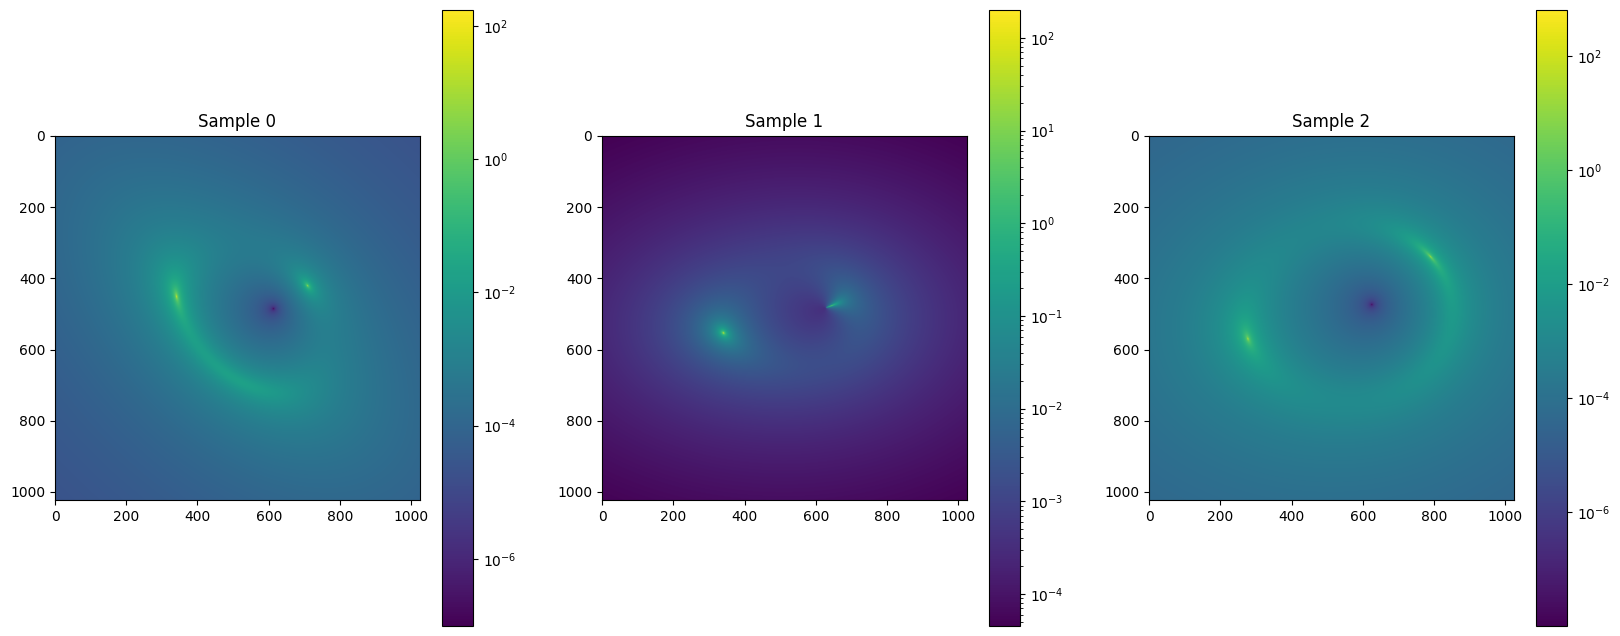

In [13]:
# simulated image with example of sampled mass distribution and truth source light
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
for i, ex in enumerate([example1, example2, example3]):
  sim_image = lens_sim.simulate([ex, [], truth_test[2]])
  im = ax[i].imshow(sim_image, norm = 'log')#, vmin=0, vmax=10)
  plt.colorbar(im, ax = ax[i])
  ax[i].set_title('Sample %i'%i)


# Calculations

In [37]:
a = ['a', 'b']
a.append(['c'])
a

['a', 'b', ['c']]


    ============== weight_dist = 1.00e+02 | weight_flux = 1.00e+02 ==============


--- Modeling a real system ----


  0%|          | 0/1000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 1000/1000 [00:06<00:00, 149.76it/s]



Best parameters:
 - theta_E   :    2.084295
   gamma     :    2.247779
   e2        :    0.135479
   e1        :    0.091175
   center_y  :    0.128674
   center_x  :    1.401897
 - gamma2    :    0.135627
   gamma1    :    0.091284


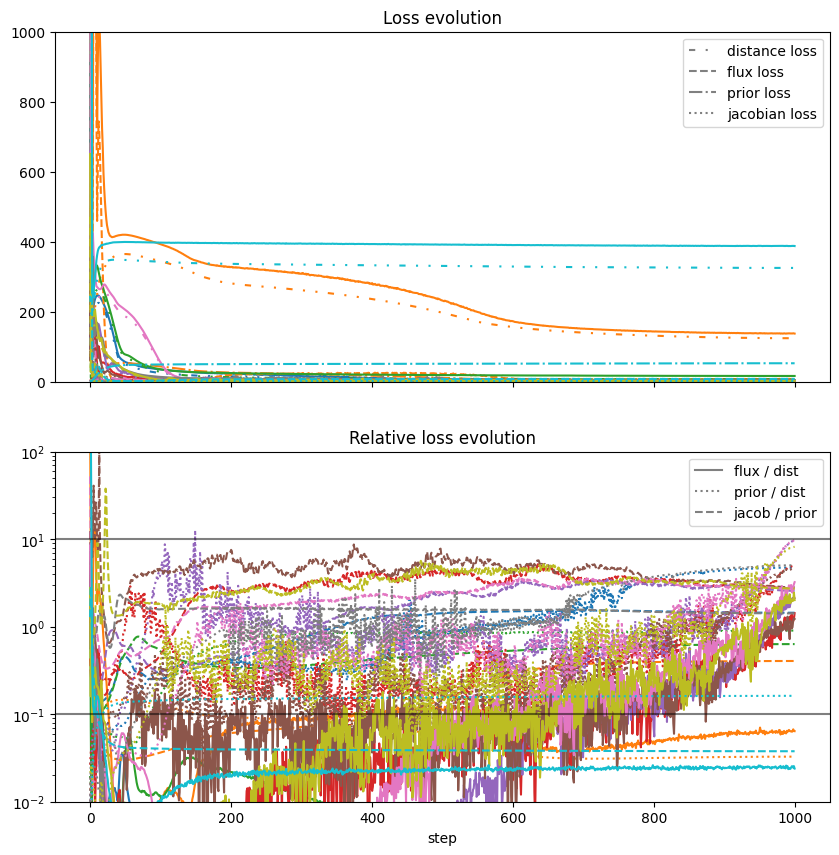


----- real system. comparing flux ratio difference ----


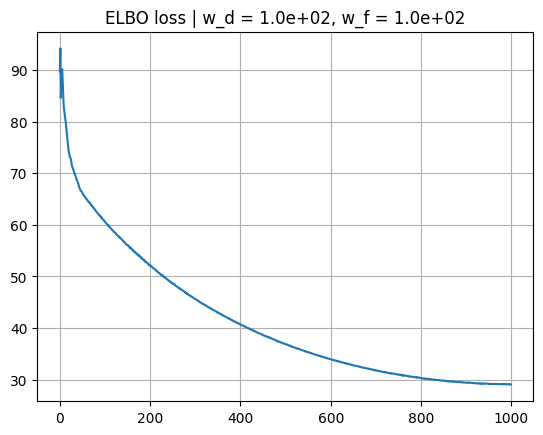


----- real system. comparing flux ratio difference ----

----------------method: adaptative------------------



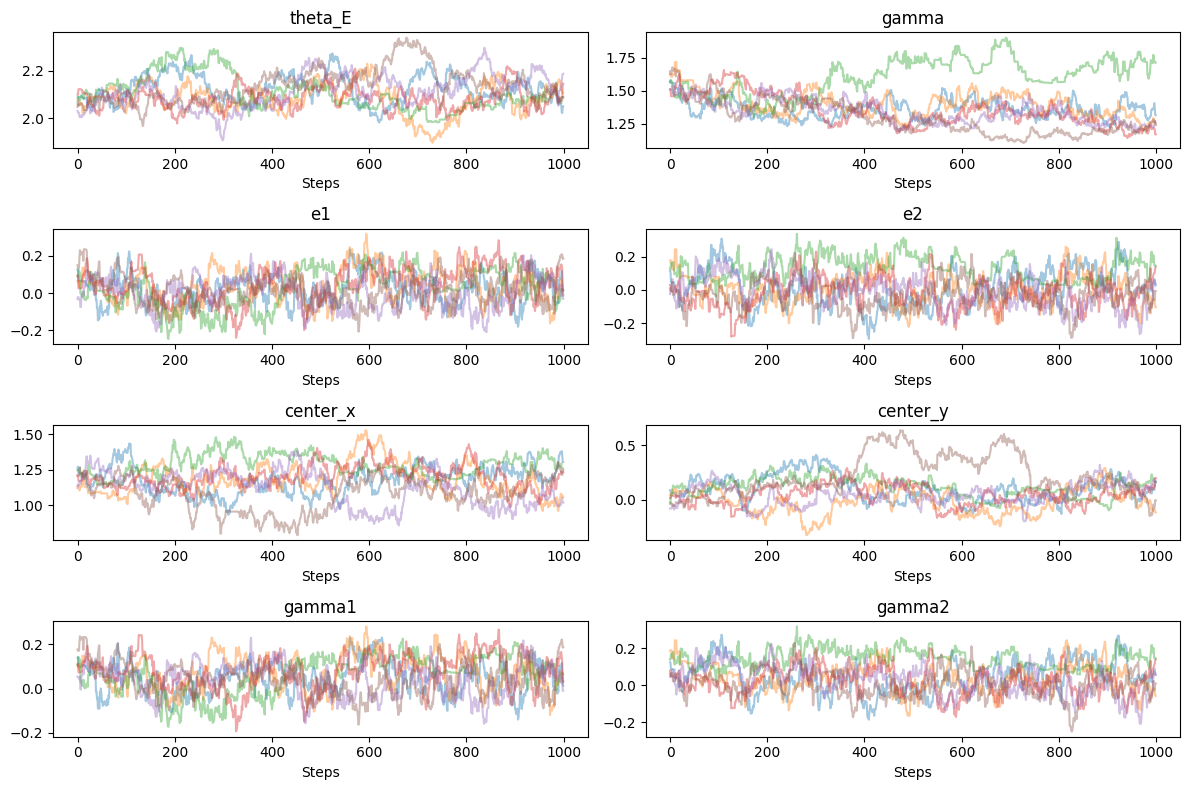


Rhat:
theta_E   :   1.271846
gamma     :   1.932780
e2        :   1.085647
e1        :   1.073447
center_y  :   1.374594
center_x  :   1.295303
gamma2    :   1.095718
gamma1    :   1.108071

ESS:
theta_E   :      939.1
gamma     :      413.5
e2        :     2733.1
e1        :     2711.9
center_y  :      734.6
center_x  :      877.7
gamma2    :     2492.3
gamma1    :     1999.7


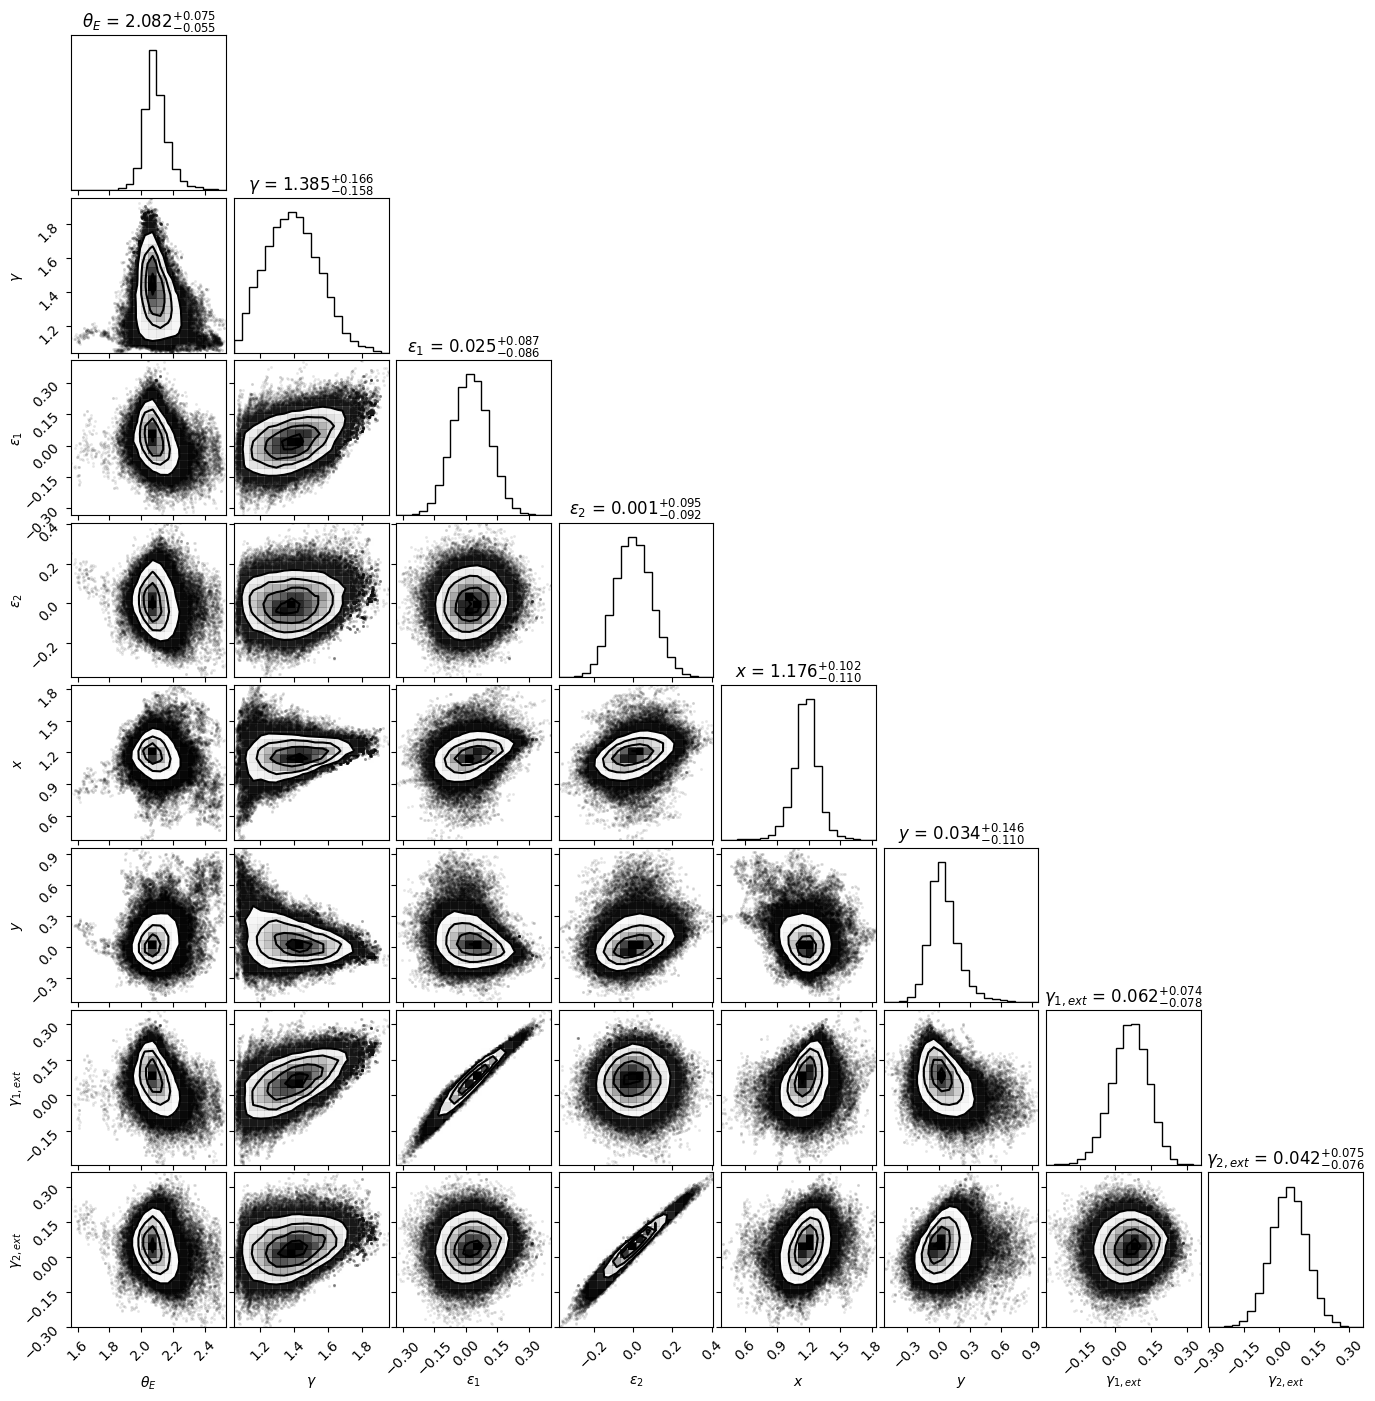

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.0920 |   2.0824
gamma      |   1.3908 |   1.3854
e1         |   0.0259 |   0.0254
e2         |   0.0028 |   0.0013
center_x   |   1.1726 |   1.1764
center_y   |   0.0541 |   0.0344
gamma1     |   0.0597 |   0.0620
gamma2     |   0.0421 |   0.0424


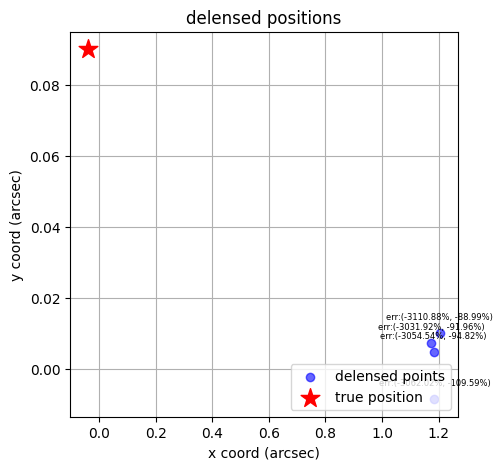

self.prob_model_output
 - theta_E   :    2.082351
   gamma     :    1.385379
   e2        :    0.001284
   e1        :    0.025365
   center_y  :    0.034365
   center_x  :    1.176414
 - gamma2    :    0.042385
   gamma1    :    0.062027


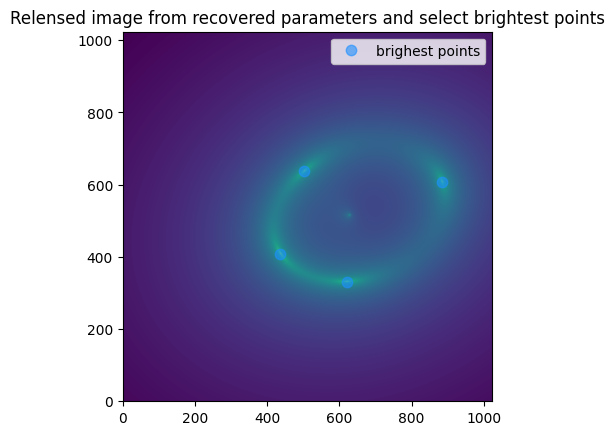

Brighest points reshaped into x, y:

x: [[-0.09454421]
 [-0.7513762 ]
 [ 3.6971679 ]
 [ 1.0797918 ]]

y: [[ 1.2489759 ]
 [-1.0300323 ]
 [ 0.95041585]
 [-1.7963363 ]]

Kwargs lens
 - theta_E   :    2.082351
   gamma     :    1.385379
   e1        :    0.025365
   e2        :    0.001284
   center_x  :    1.176414
   center_y  :    0.034365
 - gamma1    :    0.062027
   gamma2    :    0.042385


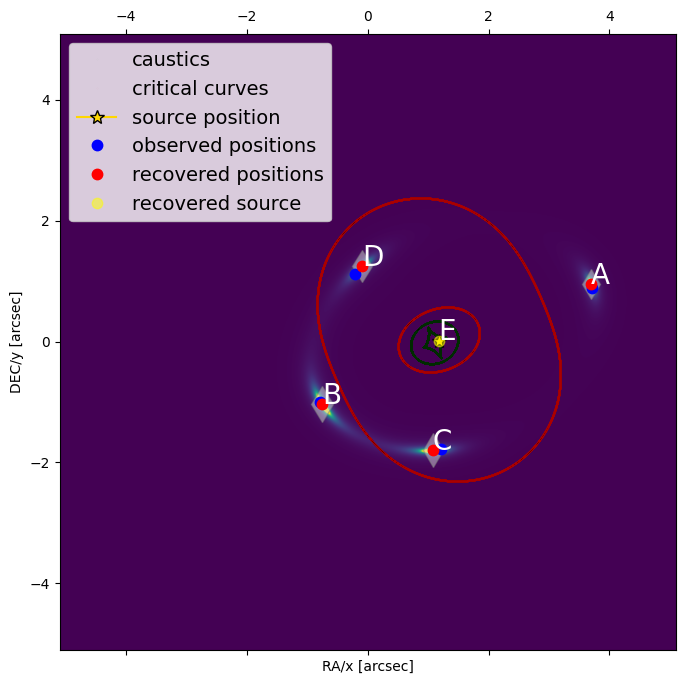


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[0.00499125]
 [0.00570578]
 [0.00832695]
 [0.00056892]
 [0.00159516]
 [0.00069553]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[0.42881405]
 [0.88346416]
 [1.8180288 ]
 [2.06025   ]
 [4.239667  ]
 [2.057841  ]]

relative errors (in observed positions):
flux1/flux2: 87.57%
flux1/flux3: 79.63%
flux1/flux4: 73.49%
flux2/flux3: 63.88%
flux2/flux4: 113.27%
flux3/flux4: 30.14%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854166], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[-23.37706 ]
 [ 39.508907]
 [ 17.979914]
 [-29.802094]]

Predicted magnifications (in observed positions):
 [[-24.60336 ]
 [ 37.571617]
 [-26.175

  0%|          | 0/1000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 1000/1000 [00:05<00:00, 169.04it/s]



Best parameters:
 - theta_E   :    2.074071
   gamma     :    2.133153
   e2        :    0.114465
   e1        :    0.113369
   center_y  :    0.079419
   center_x  :    1.402663
 - gamma2    :    0.115076
   gamma1    :    0.113976


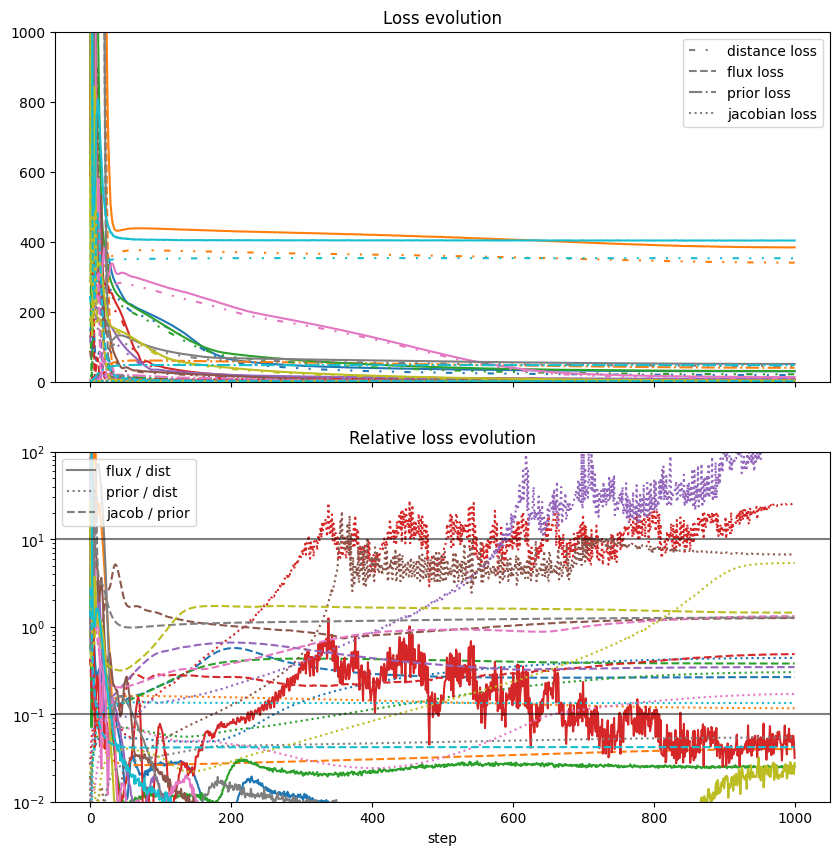


----- real system. comparing flux ratio difference ----


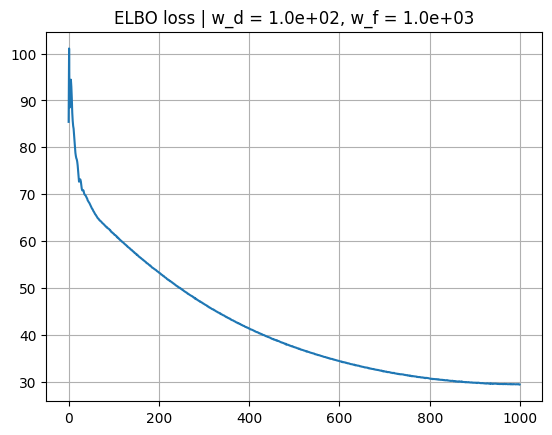


----- real system. comparing flux ratio difference ----


In [ ]:
# resolution
supersample = 1
num_pix = data.shape[0]
delta_pix = pixscale

# Modeling
observed_data = [[x_arcsec, y_arcsec], flux_truth_test]

lens_prior_chosen = lens_prior_norm

prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)

# Uniform prior
prior_uniform = tfd.JointDistributionSequential([lens_prior_uniform,])
prob_model_uniform = ForwardProbModel(prior_uniform, 0, background_rms=bkg_rms, exp_time=exptime)
losses_list = []
w_df = [[100,100], [1e2,1e3], [1e3, 1e3]]
# for wd in [10, 1e2, 1e4]: #[1, 1e2, 1e4]: #, 1e1, 1e2]: #, 5e2, 1e3, 5e3]:
#   for wf in [10, 1e2, 1e4]: #, 5e2, 1e3, 5e3]:
for weights in w_df:
    wd, wf = weights
    print('\n    ============== weight_dist = %.2e | weight_flux = %.2e ==============\n'%(wd,wf))
    analysis = LensModelAnalysis(delta_pix=pixscale, num_pix=num_pix, weight_dist=wd, weight_flux=wf, truth_test=truth_test,
                                prob_model=prob_model,
                                prior=prior,
                                #lens_prior = lens_prior,
                                phys_model = phys_model,
                                prob_model_uniform=prob_model_uniform,
                                observed_data = observed_data, simulation = False, flux_ratios = True)
    losses = analysis.run_map(n_map = 5000, n_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 1e-4, 'power': 1.0},
                    uniform_comparison = False,
                    track_loss_all = True,
                    test_results_dict = {'relative_errors': False, 
                                         'plot_loss': True, 
                                         'flux_ratio_error': False, 
                                         'delensed_positions': False,},
                    return_loss = True)
    losses_list.append(losses)
    analysis.run_vi(n_vi = 5000, num_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-2,
                                            'end_learning_rate': 1e-4,
                                            'power': 1.0})
    samples_phys = analysis.run_hmc(n_hmc=200, num_burnin_steps=200, num_results=1000, method = "adaptative",
                                     init_eps = 0.5, init_l = 3, max_leapfrog_steps = 100)
      

- keep playing with different weights, learning rates and so to test results of ELBO loss,
- then run HMC too and compare results

- learning rate has to be fixed to avoid sudden crash at the end

- remove extra map with uniform prior [x]

ELBO loss smooth plot with
```
n_map = 500, n_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 5e-3, 'power': 1.0}
```
```
n_vi = 500, num_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-5,
                                            'end_learning_rate': 4e-2,
                                            'power': 1.0}
```
- $w_d = $ 1, 10, 100 & $w_f=0$. Goes down from $\sim 70$ to $\sim 20$.
- $w_f>0$ $(w_f=0.1,\, 1, \, 10)$ more noisy but does not break down with SVI, **breaks down with HMC**